# Coagulation Kernel Tests

The Smoluchowski equation has analytical solutions for the constant, linear and product kernel and we test `mcdust` against the solutions for these kernels. To run the simulations use the following commands. 
For the constant kernel,

`make kerneltest SETUP_FILE=kernel_constant`

For the linear kernel,

`make kerneltest SETUP_FILE=kernel_linear`

For the product kernel,

`make kerneltest SETUP_FILE=kernel_product`

To remove the compilation

`make clean SETUP_FILE=kernel_linear` 

(replace `kernel_linear` with the respective kernel setup directory for other kernels.

We refer the reader to Drazkowska et al. 2013 for more details of the benchmark of the monte carlo method implemented in `mcdust` 


In [35]:
import matplotlib.pyplot as plt
import os as os
import numpy as np
import h5py
from scipy.special import gammaln

In [256]:
# The solutions from Tanaka & Nakazawa 1994

def analytical_constant_kernel(t, m, a=1.):
     """Function to compute the analytical solution for the constant kernel

        Args:
            t: dimensionless time
            m: mass grid
            a: constant for the constant coagulation kernel
        Returns:
            N*m**2: mass density for the given mass grid and time
        """         
    
        m0 = m[0]
        N0 = 1./m0
        N = N0/m0*4./(a*N0*t)**2 *np.exp((1.-m/m0)*2/(a*N0*t))
        return N*m**2
    
def analytical_linear_kernel(t,m,a=0.5):
    """Function to compute the analytical solution for the linear kernel

        Args:
            t: dimensionless time
            m: mass grid
            a: prefactor for the linear coagulation kernel
        Returns:
            N*m**2: mass density for the given mass grid and time
        """       
    m0 = m[0]
    N0 = 1./m0**2
    g = np.exp(-a*t)
    k = (m / m0)
    
    # compute it with logarithm because large numbers give numerical problems
    logN = np.log(N0*g) - k*(1.-g) + (k-1.)*np.log(k*(1.-g)) - gammaln(k+1.)
    N = np.exp(logN) 
    return N*m**2

def analytical_product_kernel(t, m):
    """Function to compute the analytical solution for the product kernel

        Args:
            t: dimensionless time
            m: mass grid
        Returns:
            N*m**2: mass density for the given mass grid and time
        """   
        # compute it with logarithm because large numbers give numerical problems
        logN = (m-1)*np.log(m*t) - m*t - gammaln(m+1.) - np.log(m)
        N = np.exp(logN) 
        return N*m**2

In [314]:
def read(type='linear',repeat = 5,nmbins=250):
    """Function to read the simulation data for the kernel tests

        Args:
            type: the kernel type used in the simulation, defaults to linear
            repeat: number of times the simulation is repeated
            nmbins: number of mass bins to build the mass grid
        Returns:
            result: a dict that containts the mass density, m2fm, values of the mass grid mgrid_cents, the output times t_arr
        """   
    if type == 'constant':
        filedir = 'kernel_constant'
        ntime = 6
    elif type == 'product':
        filedir = 'kernel_product'
        ntime = 3
    else:
        filedir = 'kernel_linear'
        ntime = 5
        
    m2fm = np.zeros((nmbins,ntime,repeat))
    mgrid_wall = np.zeros((nmbins+1,ntime,repeat))
    timearr = np.loadtxt(os.path.join('../outputs/',filedir+str(1),'timesout.dat'))
    for i in range(repeat):
        
        for j in range(ntime):
            fname = os.path.join('../outputs/',filedir+str(i+1),'out-00'+str(j+1)+'.dat')
            data = np.loadtxt(fname)
            mgrid = data[:,0]
            m2fm[:,j,i] = data[:,1]
            fname = os.path.join('../outputs/',filedir+str(i+1),'mgri00'+str(j+1)+'.dat')
            mgrid_wall[:,j,i]= np.loadtxt(fname)
    result = {
        "m2fm" :  m2fm,
        "mgrid_cents" : mgrid,
        "mgrid_wall" : mgrid_wall,
        "tarr" : timearr
    }
    return result
        

In [395]:
def plot(result,type='linear'):
    """Function to produce plot of mass density to compare the analytical kernel solutions with the simulations

        Args:
            type: the kernel type used in the simulation, defaults to linear
        """   
    start = 1
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    f,ax = plt.subplots()
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_ylim(10**-2,2)
    ax.set_ylabel('$m^2$f(m)')
    ax.set_xlabel('m')
    if (type == 'constant'):
        ax.set_xlim(1,10**6)
        ax.set_ylim(10**-2,2)
    elif (type == 'product'):
        ax.set_xlim(1,10**3)
        ax.set_ylim(10**-2,1)
    else:
        ax.set_xlim(1,10**10)
        ax.set_ylim(10**-2,4e-1)
    for it, time in enumerate(result["tarr"]):
        c = colors[it % len(colors)]
        ax.errorbar(result["mgrid_cents"][start:], 
                     np.mean(result["m2fm"][start:, it,:], axis=1),
                     yerr=np.std(result["m2fm"][start:, it, :], axis=1),
                     fmt='none', marker='.', c=c, capsize=3, ls=None)
        ax.plot(result["mgrid_cents"][start:], 
                     np.mean(result["m2fm"][start:, it,:], axis=1),
                     marker='.', c=c)
        if type == 'constant':
            ax.plot(result["mgrid_cents"],analytical_constant_kernel(time, result["mgrid_cents"],a=1),
                 c=c, ls='--')
        elif type == "product":
            ax.plot(result["mgrid_cents"],analytical_product_kernel(time, result["mgrid_cents"]),
                 c=c, ls='--')
        else:
            ax.plot(result["mgrid_cents"],analytical_linear_kernel(time, result["mgrid_cents"],a=0.5),
                 c=c, ls='--')

## Constant Kernel


$$
K (m,m')= 1.
$$

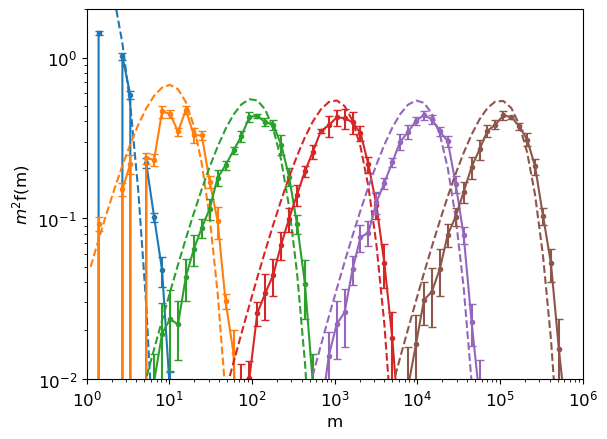

In [346]:
sim = read(type='constant')
plot(sim,type='constant')

## Linear kernel

$$
K(m,m') = 0.5(m_1 + m_2)
$$


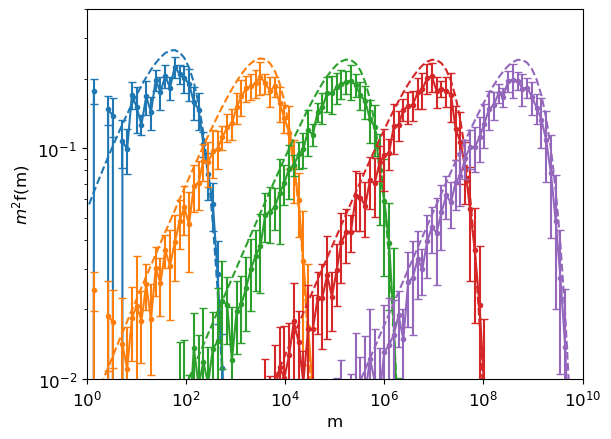

In [344]:
sim = read(type='linear',repeat=10)
plot(sim,type='linear')

## Product Kernel

$$
K(m,m') = m_1 m_2
$$

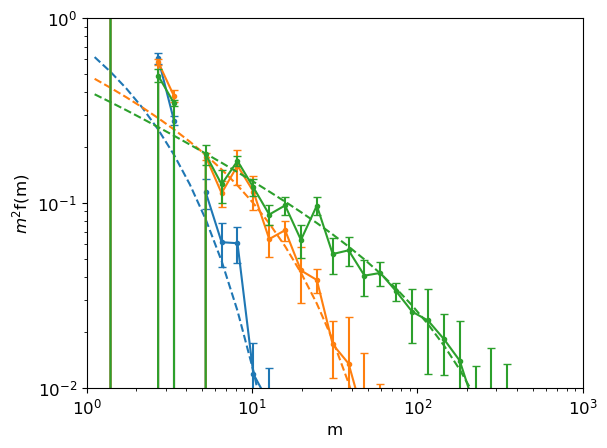

In [347]:
sim = read(type='product')
plot(sim,type='product')